# ASSIGNMENT N°1 - Machine Learning for Social Sciences (MY474)

Nicolás Hernández

### Database inspection

In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
# paths are relative to the repository root
df = pd.read_csv("data/summative_train.csv")
# Check the first 5 rows
df.head()

,y,inputstate,birthyr,gender,sexuality,trans,educ,votereg,race,employ,...,faminc_new,ownhome,urbancity,immstat,cit1,unionhh,investor,assets_estimate,response_time_minutes,volunteering_index
0,0,Washington,1944,Female,Heterosexual / straight,No,High school graduate,Yes,White,Retired,...,"$10,000 - $19,999",Own,Rural area,"My parents, grandparents and I were all born i...",Yes,"No, no one in my household has ever been a mem...",No,19068.0,19.4,0.64
1,0,Texas,1990,Male,Heterosexual / straight,No,High school graduate,Yes,Hispanic,Full-time,...,"$80,000 - $99,999",Rent,City,I was born in the USA but at least one of my p...,Yes,"No, no one in my household has ever been a mem...",No,92117.0,10.1,1.28
2,0,Massachusetts,1935,Male,Heterosexual / straight,No,4-year,Yes,White,Retired,...,"$120,000 - $149,999",Own,Suburb,"My parents, grandparents and I were all born i...",Yes,"No, no one in my household has ever been a mem...",Yes,185853.0,18.7,0.00
3,0,Michigan,1940,Male,Heterosexual / straight,No,4-year,Yes,White,Retired,...,"$40,000 - $49,999",Own,Suburb,My parents and I were born in the USA but at l...,Yes,"No, no one in my household has ever been a mem...",Yes,41921.0,13.2,0.00
4,0,New York,1959,Female,Heterosexual / straight,No,Post-grad,Yes,White,Part-time,...,"$80,000 - $99,999",Own,Suburb,I was born in the USA but at least one of my p...,Yes,"No, no one in my household has ever been a mem...",Yes,90788.0,9.0,0.00


In [19]:
# Check the shape of the dataset
df.shape

(1500, 32)

In [20]:
# Object types of the variables in the dataset
df.dtypes

y                          int64
inputstate                   str
birthyr                    int64
gender                       str
sexuality                    str
trans                        str
educ                         str
votereg                      str
race                         str
employ                       str
internethome                 str
internetwork                 str
marstat                      str
pid3                         str
ideo5                        str
pew_bornagain                str
pew_religimp                 str
pew_churatd                  str
pew_prayer                   str
religpew                     str
child18num                 int64
newsint                      str
faminc_new                   str
ownhome                      str
urbancity                    str
immstat                      str
cit1                         str
unionhh                      str
investor                     str
assets_estimate          float64
response_t

In [21]:
# Count NULL values within the dataset
df.isnull().sum()

y                          0
inputstate                 0
birthyr                    0
gender                     0
sexuality                  0
trans                      0
educ                       0
votereg                    0
race                       0
employ                     0
internethome              55
internetwork             563
marstat                    0
pid3                       0
ideo5                      0
pew_bornagain              0
pew_religimp               0
pew_churatd                0
pew_prayer                 0
religpew                   0
child18num                 0
newsint                    0
faminc_new                 0
ownhome                    0
urbancity                  0
immstat                    0
cit1                       0
unionhh                    0
investor                   0
assets_estimate            0
response_time_minutes    138
volunteering_index         0
dtype: int64

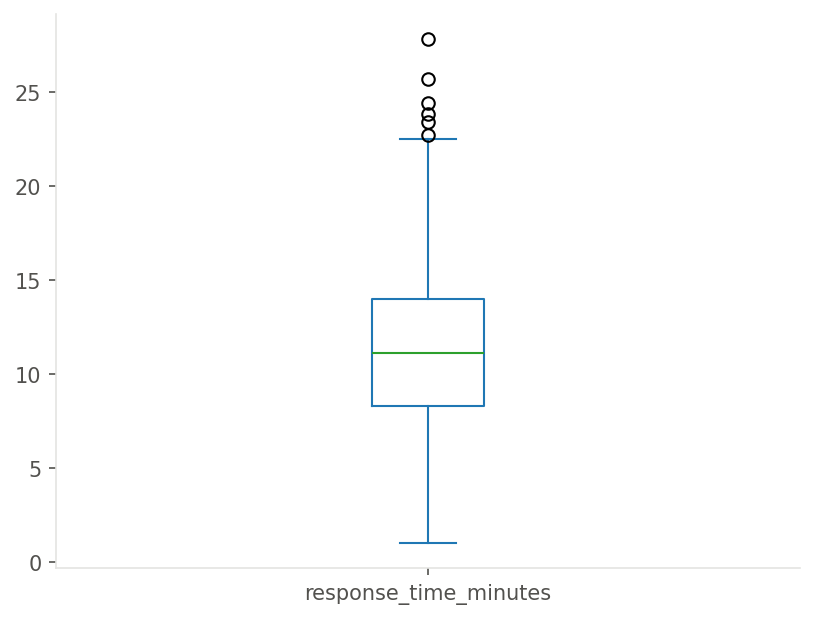

In [22]:
import matplotlib.pyplot as plt

# Graph the distribution of the numeric variable with NULL
df['response_time_minutes'].plot(kind='box')
plt.show()

In [23]:
# % distribuction of Y
df['y'].value_counts(normalize=True)

y
1    0.506
0    0.494
Name: proportion, dtype: float64

In [24]:
# Count the number of categories on categorical variables
df.select_dtypes('object').nunique()

/var/folders/23/6gsl8vnx4gz1bdhw4q7t271h0000gq/T/ipykernel_26321/3660490933.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes('object').nunique()


inputstate       50
gender            2
sexuality         6
trans             3
educ              6
votereg           3
race              8
employ            9
internethome      2
internetwork      2
marstat           6
pid3              5
ideo5             6
pew_bornagain     2
pew_religimp      4
pew_churatd       7
pew_prayer        8
religpew         12
newsint           5
faminc_new       17
ownhome           3
urbancity         5
immstat           5
cit1              2
unionhh           3
investor          2
dtype: int64

### Data cleaning and conversion

In [25]:
# Numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('y')
numeric_cols


['birthyr',
 'child18num',
 'assets_estimate',
 'response_time_minutes',
 'volunteering_index']

In [26]:
# Categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols

/var/folders/23/6gsl8vnx4gz1bdhw4q7t271h0000gq/T/ipykernel_26321/3234547143.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


['inputstate',
 'gender',
 'sexuality',
 'trans',
 'educ',
 'votereg',
 'race',
 'employ',
 'internethome',
 'internetwork',
 'marstat',
 'pid3',
 'ideo5',
 'pew_bornagain',
 'pew_religimp',
 'pew_churatd',
 'pew_prayer',
 'religpew',
 'newsint',
 'faminc_new',
 'ownhome',
 'urbancity',
 'immstat',
 'cit1',
 'unionhh',
 'investor']

In [27]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Imputation

numeric_pipe = Pipeline(steps=[
('imputer', SimpleImputer(strategy='median'))    
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy = 'constant', fill_value = 'missing')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])



In [28]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])



In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 1. Divide X and y
X = df.drop(columns='y')
y = df['y']

# 2. Redefinir columnas sobre X (sin 'y')
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# 3. Pipelines
numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 4. Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

# 5. Train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=20)

# 6. Full pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

full_pipeline.fit(X_train, y_train)
print("Accuracy en validación:", full_pipeline.score(X_val, y_val))




Accuracy en validación: 0.7266666666666667


/var/folders/23/6gsl8vnx4gz1bdhw4q7t271h0000gq/T/ipykernel_26321/2574418221.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns.tolist()
/Users/nico/Library/Python/3.11/lib/python/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/

In [30]:
print(y.value_counts(normalize=True))

y
1    0.506
0    0.494
Name: proportion, dtype: float64


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# ============================================
# IMPORTS
# ============================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# ============================================
# 1. DATA PREPARATION
# ============================================
X = df.drop(columns='y')
y = df['y']

# ============================================
# 2. IDENTIFY COLUMN TYPES
# ============================================
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# ============================================
# 3. TWO DIFFERENT NUMERIC PIPELINES
# ============================================

# Pipeline WITH scaling (for SVM, KNN, Logistic Regression)
numeric_pipe_with_scaler = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline WITHOUT scaling (for tree-based models and Naive Bayes)
numeric_pipe_without_scaler = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# ============================================
# 4. CATEGORICAL PIPELINE (same for all models)
# ============================================
categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# ============================================
# 5. TWO DIFFERENT PREPROCESSORS
# ============================================

# Preprocessor WITH scaling
preprocessor_with_scaler = ColumnTransformer(transformers=[
    ('num', numeric_pipe_with_scaler, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
], sparse_threshold=0)

# Preprocessor WITHOUT scaling
preprocessor_without_scaler = ColumnTransformer(transformers=[
    ('num', numeric_pipe_without_scaler, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
], sparse_threshold=0)

# ============================================
# 6. TRAIN/VALIDATION SPLIT
# ============================================
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=20)

# ============================================
# 7. MODELS WITH THEIR CORRECT PREPROCESSOR
# ============================================

# Models that NEED scaling
models_that_need_scaling = {
    'SVM': SVC(random_state=20),
    'KNN': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=2000, solver='liblinear')
}

# Models that do NOT need scaling
models_that_dont_need_scaling = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=20),
    'Gradient Boosting': GradientBoostingClassifier(random_state=20),
    'XGBoost': XGBClassifier(random_state=20, eval_metric='logloss'),
    'Decision Tree': DecisionTreeClassifier(random_state=20),
    'Naive Bayes': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.1)
}

# ============================================
# 8. TRAIN ALL MODELS AND STORE RESULTS
# ============================================
results = []

# Train models that NEED scaling
for nombre, modelo in models_that_need_scaling.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_with_scaler),
        ('classifier', modelo)
    ])
    pipeline.fit(X_train, y_train)
    acc = pipeline.score(X_val, y_val)
    results.append({'Model': nombre, 'Accuracy': acc, 'Scaled': 'YES'})

# Train models that do NOT need scaling
for nombre, modelo in models_that_dont_need_scaling.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_without_scaler),
        ('classifier', modelo)
    ])
    pipeline.fit(X_train, y_train)
    acc = pipeline.score(X_val, y_val)
    results.append({'Model': nombre, 'Accuracy': acc, 'Scaled': 'NO'})

# ============================================
# 9. CREATE DATAFRAME AND SORT (BEST TO WORST)
# ============================================
df_results = pd.DataFrame(results)
df_sorted = df_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# ============================================
# 10. DISPLAY SORTED RESULTS
# ============================================
print("\n" + "="*60)
print("MODELS SORTED BY ACCURACY (Best to Worst)")
print("="*60)
print(df_sorted.to_string(index=True))
print("="*60)

# ============================================
# 11. DISPLAY BEST MODEL
# ============================================
best = df_sorted.iloc[0]
print(f"BEST MODEL: {best['Model']}")
print(f"   Accuracy: {best['Accuracy']:.4f} ({best['Accuracy']*100:.2f}%)")
print(f"   Scaled: {best['Scaled']}")
print("="*60)


/var/folders/23/6gsl8vnx4gz1bdhw4q7t271h0000gq/T/ipykernel_26321/2243688156.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns.tolist()



MODELS SORTED BY ACCURACY (Best to Worst)
                 Model  Accuracy Scaled
0                  SVM  0.763333    YES
1                  QDA  0.750000     NO
2          Naive Bayes  0.730000     NO
3        Random Forest  0.723333     NO
4  Logistic Regression  0.720000    YES
5    Gradient Boosting  0.716667     NO
6                  LDA  0.703333     NO
7              XGBoost  0.680000     NO
8                  KNN  0.673333    YES
9        Decision Tree  0.610000     NO
BEST MODEL: SVM
   Accuracy: 0.7633 (76.33%)
   Scaled: YES


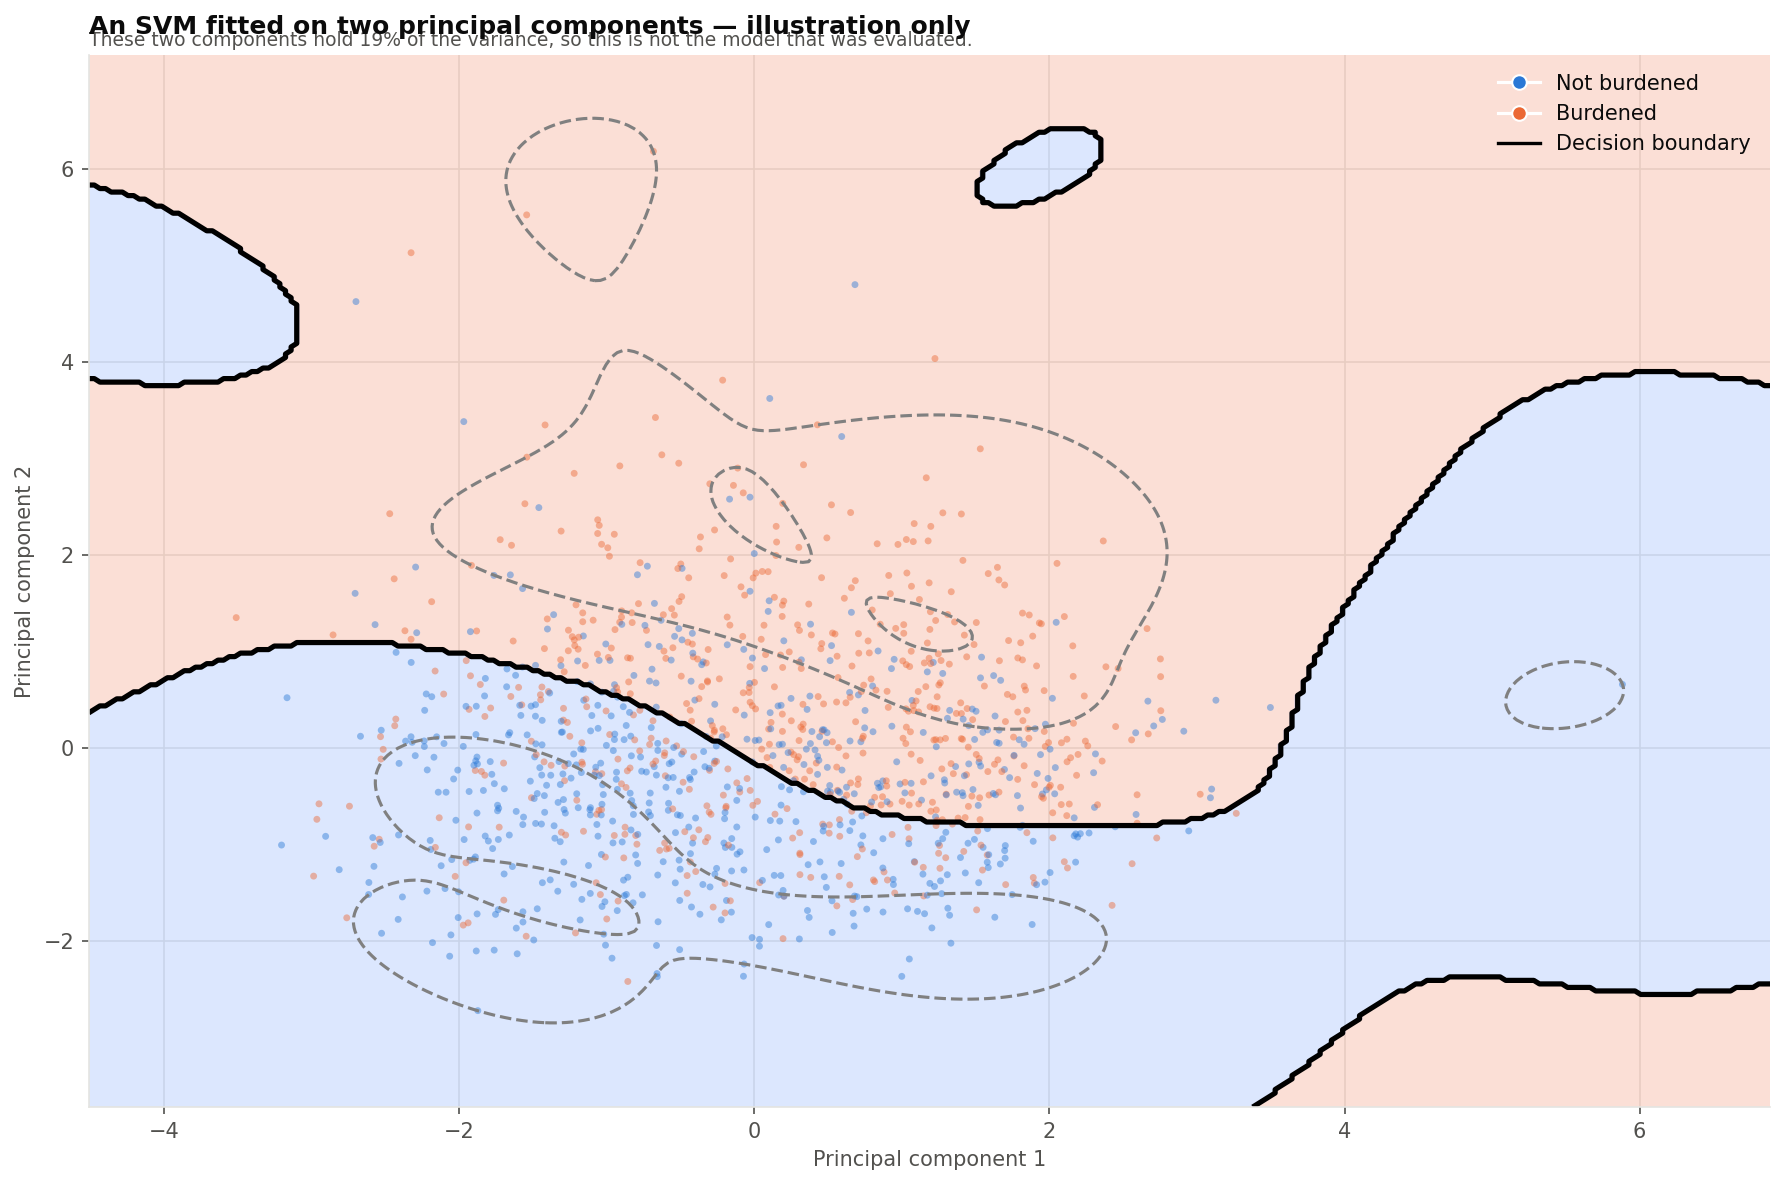

Support vectors: 886 of 1200 points (74%) — that is why they are not plotted.
Variance captured by the two components: 19.3%


In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# 1. PREPARAR DATOS PARA VISUALIZACIÓN
# ============================================
# Usar solo 2 características para poder dibujar la línea
# Elige las 2 columnas numéricas más importantes de tus datos
# (cambia estos nombres por los de tus columnas reales)

# Opción A: Si quieres usar TODAS las variables pero reducidas a 2D con PCA
preprocessor_viz = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]), categorical_cols)
], sparse_threshold=0)

# Transformar datos a espacio preprocesado
X_preprocessed = preprocessor_viz.fit_transform(X_train)

# Reducir a 2D con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_preprocessed)

# ============================================
# 2. ENTRENAR SVM EN ESPACIO 2D
# ============================================
# Creamos SVM solo para visualización (en 2D)
svm_viz = SVC(kernel='rbf', C=1.0, random_state=20)
svm_viz.fit(X_pca, y_train)

# ============================================
# 3. CREAR MALLA PARA DIBUJAR LA LÍNEA
# ============================================
# Definir límites del gráfico
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

# Crear una cuadrícula de puntos
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Predecir la clase para cada punto de la cuadrícula
Z = svm_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# ============================================
# 4. DIBUJAR LA FRONTERA DE DECISIÓN (LA LÍNEA)
# ============================================
fig, ax = plt.subplots(figsize=(12, 8))

# Dibujar las regiones de decisión (fondo)
contour = ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm', levels=[-0.5, 0.5, 1.5])

# DIBUJAR LA LÍNEA DE FRONTERA (el contorno en nivel 0)
contour_lines = ax.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2.5, linestyles='-')

# Dibujar el margen del SVM (opcional: niveles -1 y 1)
try:
    # Calcular distancia al hiperplano
    Z_decision = svm_viz.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z_decision = Z_decision.reshape(xx.shape)
    # Dibujar márgenes como líneas punteadas
    ax.contour(xx, yy, Z_decision, levels=[-1, 1], colors='gray', linewidths=1.5, linestyles='--')
except:
    pass

# ── Data points ────────────────────────────────────────────────
# Support vectors are NOT drawn: nearly every point is one, so the
# markers would cover the plot without conveying anything.
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e4e1"
BLUE, ORANGE = "#2a78d6", "#eb6834"

cols = np.where(np.asarray(y_train) == 1, ORANGE, BLUE)
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=cols, s=11, alpha=0.45, linewidths=0)

ax.set_title(
    "An SVM fitted on two principal components — illustration only",
    loc="left", fontsize=12, fontweight="bold", color=INK, pad=10)
ax.text(0.0, 1.005,
        f"These two components hold {pca.explained_variance_ratio_.sum():.0%} "
        f"of the variance, so this is not the model that was evaluated.",
        transform=ax.transAxes, fontsize=9, color=MUTED, va="bottom")
ax.set_xlabel("Principal component 1", color=MUTED)
ax.set_ylabel("Principal component 2", color=MUTED)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], marker="o", color="w", label="Not burdened",
           markerfacecolor=BLUE, markersize=7),
    Line2D([0], [0], marker="o", color="w", label="Burdened",
           markerfacecolor=ORANGE, markersize=7),
    Line2D([0], [0], color="black", lw=1.6, label="Decision boundary"),
], frameon=False, loc="upper right")

for side in ("top", "right"): ax.spines[side].set_visible(False)
ax.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"Support vectors: {len(svm_viz.support_vectors_)} of {len(X_pca)} points "
      f"({len(svm_viz.support_vectors_)/len(X_pca):.0%}) — that is why they are not plotted.")
print(f"Variance captured by the two components: {pca.explained_variance_ratio_.sum():.1%}")


## Model comparison

Ten algorithms scored on the validation split with five metrics each.
Writes `outputs/tables/09_model_comparison.csv` and defines `comparison`,
which the figures below depend on.


In [33]:
# ─────────────────────────────────────────────────────────────
# Paste this as a NEW CELL at the end of modelling.ipynb and run it.
# It uses your own variable names, so nothing needs editing.
# Requires that cell 16 has already run (the one that builds df_sorted).
# ─────────────────────────────────────────────────────────────

import os, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

os.makedirs("outputs/tables", exist_ok=True)

rows = []
for label, model in {**models_that_need_scaling, **models_that_dont_need_scaling}.items():
    prep = (preprocessor_with_scaler if label in models_that_need_scaling
            else preprocessor_without_scaler)
    pipe = Pipeline([("preprocessor", prep), ("classifier", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)

    # ROC AUC needs scores; not every classifier exposes predict_proba
    try:
        score = pipe.predict_proba(X_val)[:, 1]
    except AttributeError:
        try:
            score = pipe.decision_function(X_val)
        except AttributeError:
            score = None

    rows.append({
        "Model":     label,
        "Scaled":    "yes" if label in models_that_need_scaling else "no",
        "Accuracy":  round(accuracy_score(y_val, pred), 3),
        "Precision": round(precision_score(y_val, pred, zero_division=0), 3),
        "Recall":    round(recall_score(y_val, pred, zero_division=0), 3),
        "F1":        round(f1_score(y_val, pred, zero_division=0), 3),
        "ROC AUC":   round(roc_auc_score(y_val, score), 3) if score is not None else None,
    })

comparison = (pd.DataFrame(rows)
              .sort_values("ROC AUC", ascending=False, na_position="last")
              .reset_index(drop=True))

comparison.to_csv("outputs/tables/09_model_comparison.csv", index=False)
print(f"Saved outputs/tables/09_model_comparison.csv — {len(comparison)} models")
comparison


Saved outputs/tables/09_model_comparison.csv — 10 models


,Model,Scaled,Accuracy,Precision,Recall,F1,ROC AUC
0,SVM,yes,0.763,0.774,0.769,0.772,0.816
1,Logistic Regression,yes,0.720,0.731,0.731,0.731,0.797
2,Gradient Boosting,no,0.717,0.752,0.679,0.714,0.797
3,QDA,no,0.750,0.768,0.744,0.756,0.794
4,Naive Bayes,no,0.730,0.762,0.699,0.729,0.793
5,Random Forest,no,0.723,0.752,0.699,0.724,0.789
6,LDA,no,0.703,0.716,0.712,0.714,0.785
7,XGBoost,no,0.680,0.683,0.718,0.700,0.770
8,KNN,yes,0.673,0.684,0.692,0.688,0.736
9,Decision Tree,no,0.610,0.623,0.635,0.629,0.609


## Figures for the README

Model ranking by ROC AUC, and how well the winner separates the two classes.


F1 is maximised at threshold 0.37 (F1 0.779) — against 0.721 at the default 0.5


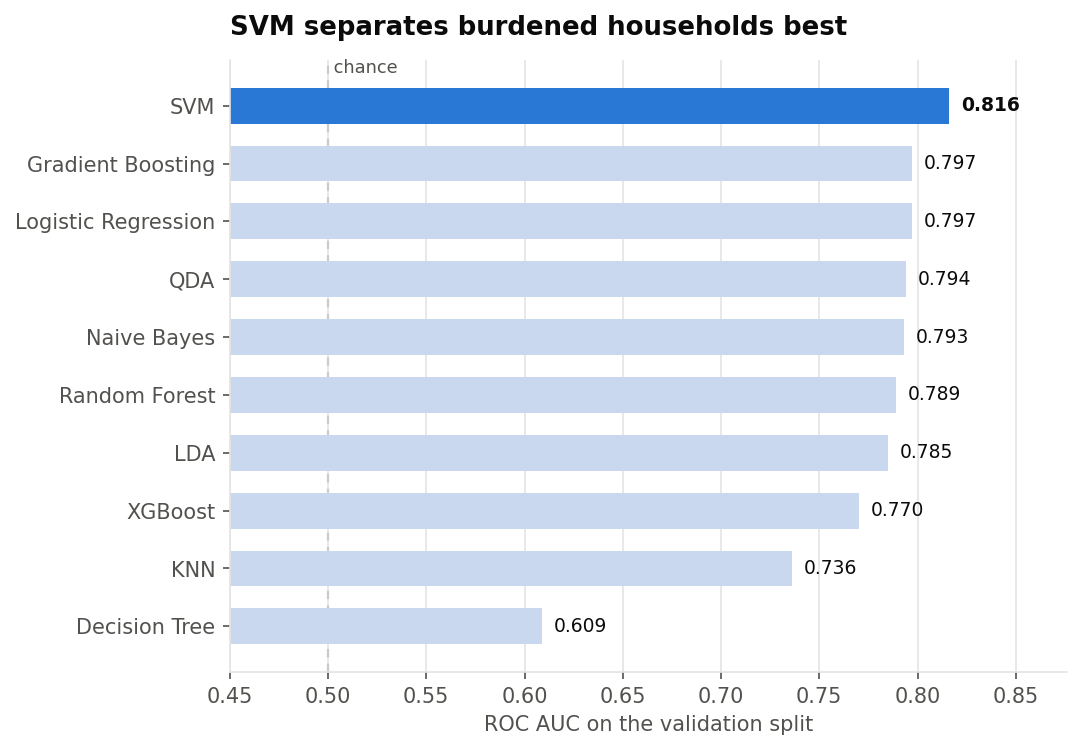

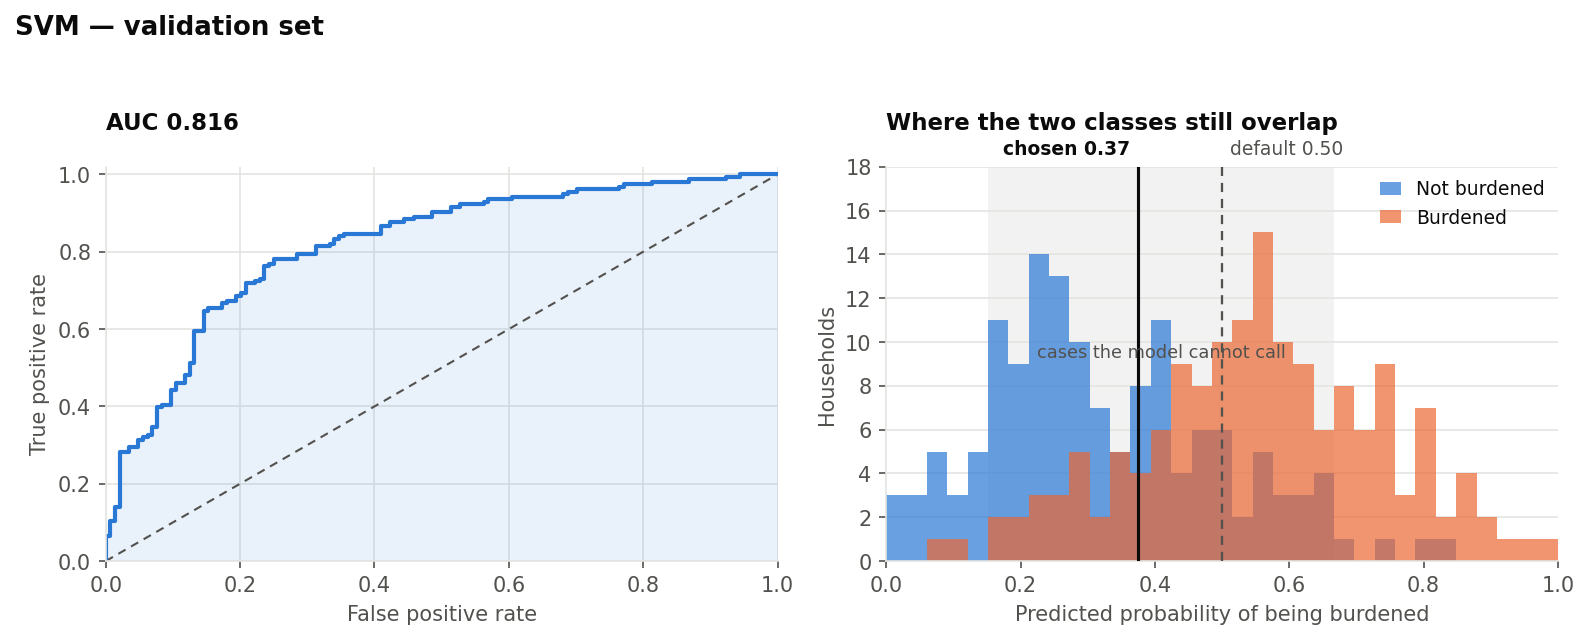

saved outputs/figures/03_model_ranking.png and 04_class_separation.png


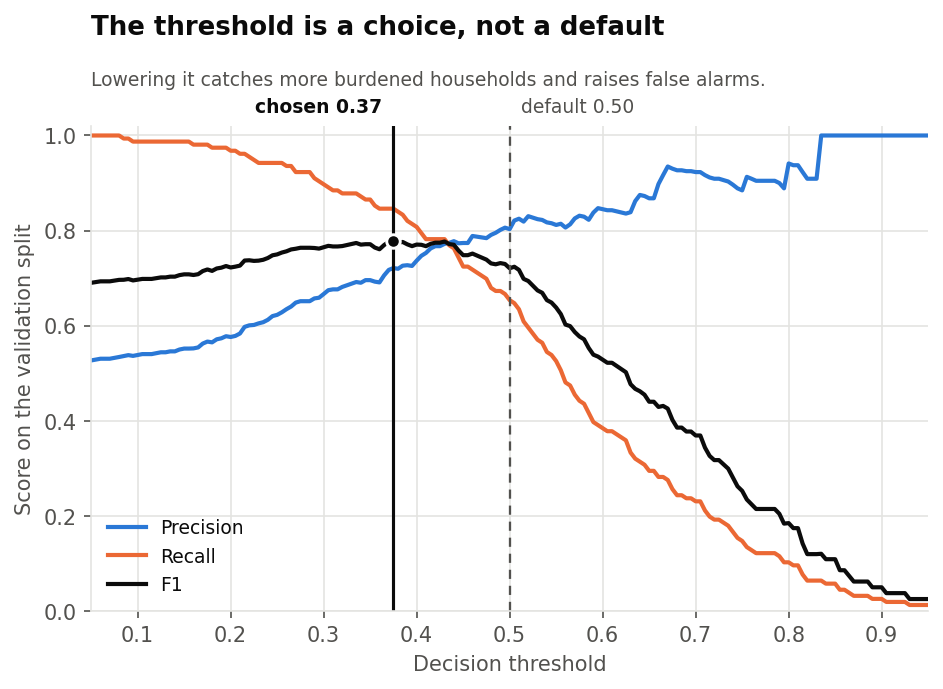

saved outputs/figures/05_threshold_choice.png and outputs/tables/10_threshold_sweep.csv


/Users/nico/Library/Python/3.11/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [22, 23] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/nico/Library/Python/3.11/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/nico/Library/Python/3.11/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [19] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/nico/Library/Python/3.11/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/nico/Library/Python/3.11/lib/py

Brier score            0.1855
  baseline (base rate) 0.2496
  skill score          +0.257   (0 = no better than the base rate, 1 = perfect)
  after isotonic recal 0.1759   (better)


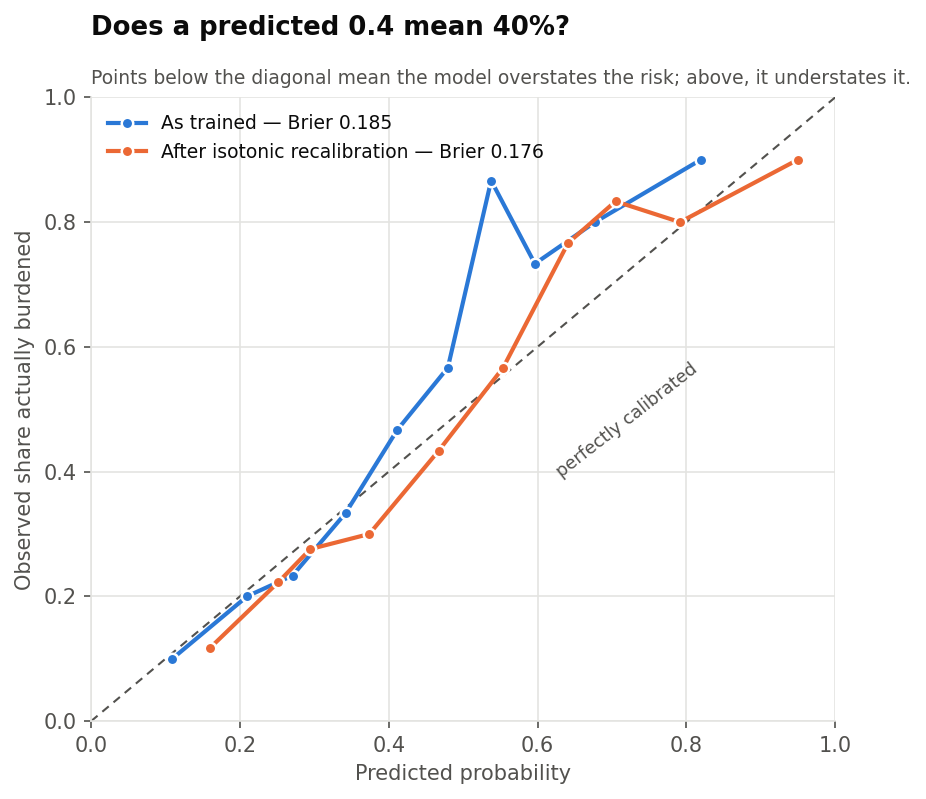

saved outputs/figures/06_calibration.png and outputs/tables/11_probability_quality.csv
FINAL MODEL: SVM + isotonic recalibration
  Brier      0.1759   (skill +0.295)
  ROC AUC    0.8166
  Threshold  0.45   (was 0.37 on the uncalibrated model)
  F1         0.7802
  written to burden.pickle
  saved outputs/tables/12_final_model.csv


In [34]:
# ─────────────────────────────────────────────────────────────
# Two figures for the README. Run after the model-comparison cell.
# ─────────────────────────────────────────────────────────────
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_curve, roc_auc_score, recall_score,
                             precision_score)

os.makedirs("outputs/figures", exist_ok=True)

INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e4e1"
BLUE, ORANGE     = "#2a78d6", "#eb6834"      # validated CVD-safe pair
plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 10, "text.color": INK,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
})

# ── refit the winner to get validation-set scores ──────────────
best_name = comparison.iloc[0]["Model"]
best_est  = {**models_that_need_scaling, **models_that_dont_need_scaling}[best_name]
prep = (preprocessor_with_scaler if best_name in models_that_need_scaling
        else preprocessor_without_scaler)
best_pipe = Pipeline([("preprocessor", prep), ("classifier", best_est)]).fit(X_train, y_train)
try:    p = best_pipe.predict_proba(X_val)[:, 1]
except AttributeError:
    s = best_pipe.decision_function(X_val); p = (s - s.min()) / (s.max() - s.min())
auc = roc_auc_score(y_val, p)

# ── pick the threshold instead of inheriting 0.5 ───────────────
from sklearn.metrics import precision_recall_curve, f1_score
grid  = np.linspace(0.05, 0.95, 181)
f1s   = np.array([f1_score(y_val, (p >= t).astype(int), zero_division=0) for t in grid])
recs  = np.array([recall_score(y_val, (p >= t).astype(int), zero_division=0) for t in grid])
precs = np.array([precision_score(y_val, (p >= t).astype(int), zero_division=0) for t in grid])
t_best = float(grid[f1s.argmax()])
print(f"F1 is maximised at threshold {t_best:.2f} (F1 {f1s.max():.3f}) "
      f"— against {f1_score(y_val, (p >= .5).astype(int)):.3f} at the default 0.5")


def _label_thresholds(ax, t_best, y=1.02):
    """Place the two threshold labels so they never collide, however
    close the values are: the lower one reads leftwards, the upper
    one rightwards."""
    lo, hi = (t_best, .5) if t_best < .5 else (.5, t_best)
    lo_txt = f"chosen {t_best:.2f}" if t_best < .5 else "default 0.50"
    hi_txt = "default 0.50" if t_best < .5 else f"chosen {t_best:.2f}"
    lo_col = INK if t_best < .5 else MUTED
    hi_col = MUTED if t_best < .5 else INK
    ax.annotate(lo_txt, xy=(lo - .012, y), xycoords=("data", "axes fraction"),
                ha="right", va="bottom", fontsize=9, color=lo_col,
                fontweight="bold" if lo_col == INK else "normal")
    ax.annotate(hi_txt, xy=(hi + .012, y), xycoords=("data", "axes fraction"),
                ha="left", va="bottom", fontsize=9, color=hi_col,
                fontweight="bold" if hi_col == INK else "normal")

# ── FIGURE 1 · which model, ranked ─────────────────────────────
d = comparison.dropna(subset=["ROC AUC"]).sort_values("ROC AUC")
fig, ax = plt.subplots(figsize=(7.2, 0.42 * len(d) + 1.1))
colors = [BLUE if m == best_name else "#c9d8ef" for m in d["Model"]]
ax.barh(d["Model"], d["ROC AUC"], color=colors, height=0.62)
ax.axvline(0.5, color=MUTED, lw=1, ls=(0, (4, 3)), zorder=0)
ax.text(0.5, len(d) - 0.35, " chance", color=MUTED, fontsize=8.5, va="center")
for i, (v, m) in enumerate(zip(d["ROC AUC"], d["Model"])):
    ax.text(v + 0.006, i, f"{v:.3f}", va="center", fontsize=9,
            color=INK, fontweight="bold" if m == best_name else "normal")
ax.set_xlim(0.45, max(d["ROC AUC"]) + 0.06)
ax.set_xlabel("ROC AUC on the validation split")
ax.set_title(f"{best_name} separates burdened households best",
             loc="left", fontsize=12.5, fontweight="bold", color=INK, pad=12)
ax.xaxis.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
fig.savefig("outputs/figures/03_model_ranking.png"); plt.show()

# ── FIGURE 2 · how well it separates ───────────────────────────
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))

fpr, tpr, _ = roc_curve(y_val, p)
a1.plot([0, 1], [0, 1], color=MUTED, lw=1, ls=(0, (4, 3)))
a1.plot(fpr, tpr, color=BLUE, lw=2)
a1.fill_between(fpr, tpr, alpha=0.10, color=BLUE, lw=0)
a1.set_xlabel("False positive rate"); a1.set_ylabel("True positive rate")
a1.set_title(f"AUC {auc:.3f}", loc="left", fontsize=11, color=INK, fontweight="bold")
a1.grid(True, color=GRID, lw=0.8); a1.set_axisbelow(True)
a1.set_xlim(0, 1); a1.set_ylim(0, 1.02)

bins = np.linspace(0, 1, 34)
h0, _ = np.histogram(p[y_val == 0], bins=bins)
h1, _ = np.histogram(p[y_val == 1], bins=bins)
top = max(h0.max(), h1.max())

# shade the band where both classes are still common — the hard cases
both = (h0 > top * .12) & (h1 > top * .12)
if both.any():
    lo, hi = bins[:-1][both].min(), bins[1:][both].max()
    a2.axvspan(lo, hi, color=MUTED, alpha=.07, lw=0, zorder=0)
    a2.annotate("cases the model cannot call",
                xy=((lo + hi) / 2, top * .62), ha="center", fontsize=8.5,
                color=MUTED, zorder=5)

a2.hist(p[y_val == 0], bins=bins, color=BLUE,   alpha=.70, lw=0, label="Not burdened")
a2.hist(p[y_val == 1], bins=bins, color=ORANGE, alpha=.70, lw=0, label="Burdened")
a2.axvline(.5, color=MUTED, lw=1.1, ls=(0, (4, 3)), zorder=4)
a2.axvline(t_best, color=INK, lw=1.5, zorder=4)
_label_thresholds(a2, t_best)

a2.set_ylim(0, top * 1.20)
a2.set_xlim(0, 1)
a2.set_xlabel("Predicted probability of being burdened")
a2.set_ylabel("Households")
a2.set_title("Where the two classes still overlap", loc="left", fontsize=11,
             color=INK, fontweight="bold", pad=18)
a2.legend(frameon=False, loc="upper right", fontsize=9,
          handlelength=1.1, borderpad=0.2)
a2.grid(True, axis="y", color=GRID, lw=0.8); a2.set_axisbelow(True)

a1.set_title(f"AUC {auc:.3f}", loc="left", fontsize=11, color=INK,
             fontweight="bold", pad=18)

fig.suptitle(f"{best_name} — validation set", x=0.005, ha="left",
             fontsize=12.5, fontweight="bold", color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("outputs/figures/04_class_separation.png"); plt.show()

print("saved outputs/figures/03_model_ranking.png and 04_class_separation.png")


# ── FIGURE 3 · why that threshold ──────────────────────────────
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(grid, precs, color=BLUE,   lw=2, label="Precision")
ax.plot(grid, recs,  color=ORANGE, lw=2, label="Recall")
ax.plot(grid, f1s,   color=INK,    lw=2, label="F1")
ax.axvline(.5, color=MUTED, lw=1.1, ls=(0, (4, 3)))
ax.axvline(t_best, color=INK, lw=1.5)
_label_thresholds(ax, t_best)
ax.scatter([t_best], [f1s.max()], s=42, color=INK, zorder=5,
           edgecolors="white", linewidths=1.4)
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Score on the validation split")
ax.set_xlim(0.05, 0.95); ax.set_ylim(0, 1.02)
ax.set_title("The threshold is a choice, not a default",
             loc="left", fontsize=12.5, fontweight="bold", color=INK, pad=44)
ax.text(0, 1.075, "Lowering it catches more burdened households and raises false alarms.",
        transform=ax.transAxes, fontsize=9, color=MUTED, va="bottom")
ax.legend(frameon=False, loc="lower left", fontsize=9)
ax.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
fig.savefig("outputs/figures/05_threshold_choice.png"); plt.show()

pd.DataFrame({"threshold": grid, "precision": precs, "recall": recs, "f1": f1s}) \
  .round(4).to_csv("outputs/tables/10_threshold_sweep.csv", index=False)
print("saved outputs/figures/05_threshold_choice.png and outputs/tables/10_threshold_sweep.csv")


# ── FIGURE 4 · are the probabilities honest? ───────────────────
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

base_rate = float(np.mean(y_val))
brier      = brier_score_loss(y_val, p)
brier_base = base_rate * (1 - base_rate)          # always predicting the base rate
skill      = 1 - brier / brier_base                # Brier skill score

# does calibrating the winner help?
cal = CalibratedClassifierCV(best_pipe, method="isotonic", cv=5).fit(X_train, y_train)
p_cal = cal.predict_proba(X_val)[:, 1]
brier_cal = brier_score_loss(y_val, p_cal)

print(f"Brier score            {brier:.4f}")
print(f"  baseline (base rate) {brier_base:.4f}")
print(f"  skill score          {skill:+.3f}   (0 = no better than the base rate, 1 = perfect)")
print(f"  after isotonic recal {brier_cal:.4f}   ({'better' if brier_cal < brier else 'no better'})")

fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls=(0, (4, 3)))
ax.annotate("perfectly calibrated", xy=(.62, .58), rotation=38, fontsize=8.5,
            color=MUTED, ha="left", va="top")
for probs, colour, lab, bs in ((p, BLUE, "As trained", brier),
                               (p_cal, ORANGE, "After isotonic recalibration", brier_cal)):
    xs, ys = calibration_curve(y_val, probs, n_bins=10, strategy="quantile")
    ax.plot(ys, xs, color=colour, lw=2, marker="o", ms=5.5,
            markeredgecolor="white", markeredgewidth=1.2,
            label=f"{lab} — Brier {bs:.3f}")
ax.set_xlabel("Predicted probability"); ax.set_ylabel("Observed share actually burdened")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("Does a predicted 0.4 mean 40%?", loc="left",
             fontsize=12.5, fontweight="bold", color=INK, pad=30)
ax.text(0, 1.015, "Points below the diagonal mean the model overstates the risk; above, it understates it.",
        transform=ax.transAxes, fontsize=9, color=MUTED, va="bottom")
ax.legend(frameon=False, loc="upper left", fontsize=9)
ax.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
fig.savefig("outputs/figures/06_calibration.png"); plt.show()

pd.DataFrame([{"metric": "Brier score", "value": round(brier, 4)},
              {"metric": "Brier, base-rate baseline", "value": round(brier_base, 4)},
              {"metric": "Brier skill score", "value": round(skill, 4)},
              {"metric": "Brier after isotonic recalibration", "value": round(brier_cal, 4)},
              {"metric": "ROC AUC", "value": round(auc, 4)},
              {"metric": "Chosen threshold", "value": round(t_best, 3)}]
             ).to_csv("outputs/tables/11_probability_quality.csv", index=False)
print("saved outputs/figures/06_calibration.png and outputs/tables/11_probability_quality.csv")


# ── Keep whichever version has the better Brier score ──────────
import pickle

if brier_cal < brier:
    final_model, p_final, final_brier = cal, p_cal, brier_cal
    final_label = f"{best_name} + isotonic recalibration"
else:
    final_model, p_final, final_brier = best_pipe, p, brier
    final_label = best_name

# the threshold has to be recomputed: recalibration rescales the probabilities
f1_final = np.array([f1_score(y_val, (p_final >= t).astype(int), zero_division=0) for t in grid])
t_final  = float(grid[f1_final.argmax()])

print(f"FINAL MODEL: {final_label}")
print(f"  Brier      {final_brier:.4f}   (skill {1 - final_brier/brier_base:+.3f})")
print(f"  ROC AUC    {roc_auc_score(y_val, p_final):.4f}")
print(f"  Threshold  {t_final:.2f}   (was {t_best:.2f} on the uncalibrated model)")
print(f"  F1         {f1_final.max():.4f}")

with open("burden.pickle", "wb") as f:
    pickle.dump(final_model, f)
print("  written to burden.pickle")

pd.DataFrame([{"metric": "Model",             "value": final_label},
              {"metric": "Brier score",       "value": round(final_brier, 4)},
              {"metric": "Brier skill score", "value": round(1 - final_brier/brier_base, 4)},
              {"metric": "ROC AUC",           "value": round(roc_auc_score(y_val, p_final), 4)},
              {"metric": "Decision threshold","value": round(t_final, 3)},
              {"metric": "F1 at that threshold","value": round(f1_final.max(), 4)},
              {"metric": "Precision",         "value": round(precision_score(y_val,(p_final>=t_final).astype(int)), 4)},
              {"metric": "Recall",            "value": round(recall_score(y_val,(p_final>=t_final).astype(int)), 4)},
             ]).to_csv("outputs/tables/12_final_model.csv", index=False)
print("  saved outputs/tables/12_final_model.csv")
